# Notebook 2: The Goldbach Connection
## Untouchable Numbers — Beautiful Dead Ends

---

### Why the conjecture is hard

In Notebook 1 we established that untouchable numbers exist, computed them
up to 1000, and noticed that their density appears to grow. The natural question
is: are there infinitely many?

Almost certainly yes. But proving it requires something we don't have.

The connection to Goldbach's Conjecture is not an analogy or a loose comparison.
It is direct and precise: a proof that there are infinitely many untouchable
numbers would follow from Goldbach, and conversely, progress on untouchable
numbers is blocked by exactly the same gap that blocks Goldbach.

This notebook makes that connection explicit.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

plt.style.use('dark_background')
ACCENT  = '#e05c5c'
NEUTRAL = '#888888'
BLUE    = '#5c9ee0'
GREEN   = '#5ce08a'
AMBER   = '#e0a05c'

def proper_divisors_sum(n):
    if n <= 1: return 0
    divs = [1]
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            divs.append(i)
            if i != n // i:
                divs.append(n // i)
    return sum(divs)

def is_prime(n):
    if n < 2: return False
    if n == 2: return True
    if n % 2 == 0: return False
    for i in range(3, int(n**0.5) + 1, 2):
        if n % i == 0: return False
    return True

LIMIT  = 1000
SEARCH = LIMIT * 10

reachable = set()
for n in range(2, SEARCH):
    s = proper_divisors_sum(n)
    if s <= LIMIT:
        reachable.add(s)

untouchable = [m for m in range(1, LIMIT+1) if m not in reachable]
print(f'Setup complete. {len(untouchable)} untouchable numbers up to {LIMIT}.')

Setup complete. 172 untouchable numbers up to 1000.


## The key algebraic fact

To understand the Goldbach connection we need to know what values s(n) can
take for different types of n. The most important case is the simplest one:
**semiprimes** — products of exactly two primes.

If p is an odd prime, what is s(2p)?
The proper divisors of 2p are: 1, 2, and p.
So s(2p) = 1 + 2 + p = **p + 3**... wait, that's not right. Let me be careful.

Actually: proper divisors of 2p (where p is an odd prime, p ≠ 2) are 1, 2, p.
Sum = 1 + 2 + p = p + 3. Hmm — let me verify computationally.

Actually s(2p) = 1 + p (the divisors of 2p are 1, 2, p, 2p — proper ones are 1, 2, p,
summing to p+3). Let me just compute it directly.

In [2]:
# Compute s(n) for semiprimes of the form 2p
print('s(2p) for odd primes p:')
for p in [3, 5, 7, 11, 13, 17, 19, 23, 29, 31]:
    n = 2 * p
    s = proper_divisors_sum(n)
    divs = [d for d in range(1, n) if n % d == 0]
    print(f'  s(2×{p:2d}) = s({n:3d}): divisors={divs}, s={s}, s = p+3 = {p+3}? {s == p+3}')

print()
print('So: s(2p) = p + 3 for odd primes p')
print('Equivalently: m is touchable via 2p if m = p + 3, i.e. m-3 is an odd prime')
print()

# Also check s(p^2)
print('s(p²) for odd primes p:')
for p in [3, 5, 7, 11, 13]:
    n = p**2
    s = proper_divisors_sum(n)
    print(f'  s({p}²) = s({n:4d}) = {s} = p+1 = {p+1}? {s == p+1}')
print()
print('So: s(p²) = p + 1 for odd primes p')
print('Equivalently: m is touchable via p² if m = p+1, i.e. m-1 is an odd prime')

s(2p) for odd primes p:
  s(2× 3) = s(  6): divisors=[1, 2, 3], s=6, s = p+3 = 6? True
  s(2× 5) = s( 10): divisors=[1, 2, 5], s=8, s = p+3 = 8? True
  s(2× 7) = s( 14): divisors=[1, 2, 7], s=10, s = p+3 = 10? True
  s(2×11) = s( 22): divisors=[1, 2, 11], s=14, s = p+3 = 14? True
  s(2×13) = s( 26): divisors=[1, 2, 13], s=16, s = p+3 = 16? True
  s(2×17) = s( 34): divisors=[1, 2, 17], s=20, s = p+3 = 20? True
  s(2×19) = s( 38): divisors=[1, 2, 19], s=22, s = p+3 = 22? True
  s(2×23) = s( 46): divisors=[1, 2, 23], s=26, s = p+3 = 26? True
  s(2×29) = s( 58): divisors=[1, 2, 29], s=32, s = p+3 = 32? True
  s(2×31) = s( 62): divisors=[1, 2, 31], s=34, s = p+3 = 34? True

So: s(2p) = p + 3 for odd primes p
Equivalently: m is touchable via 2p if m = p + 3, i.e. m-3 is an odd prime

s(p²) for odd primes p:
  s(3²) = s(   9) = 4 = p+1 = 4? True
  s(5²) = s(  25) = 6 = p+1 = 6? True
  s(7²) = s(  49) = 8 = p+1 = 8? True
  s(11²) = s( 121) = 12 = p+1 = 12? True
  s(13²) = s( 169) = 14 = p+1 = 

## The two main routes to touching even numbers

For an even number m to be **touchable**, one of these needs to work:

**Route 1:** Find an odd prime p such that m = p + 1.
Then s(p²) = p + 1 = m. ✓
This works if and only if **m − 1 is an odd prime**.

**Route 2:** Find an odd prime p such that m = p + 3.
Then s(2p) = p + 3 = m. ✓
This works if and only if **m − 3 is an odd prime**.

**Route 3:** Other algebraic forms — s(p³), s(p²q), s(2^k), etc.
These provide additional coverage but are less systematic.

For an even number m to be **untouchable**, ALL routes must fail simultaneously.

This is already saying something: an even m is a candidate for untouchability
if m−1 is not prime AND m−3 is not prime. Let's see how many of our
untouchable numbers satisfy this.

In [3]:
even_unt = [m for m in untouchable if m % 2 == 0]

print('Even untouchable numbers and their primality tests:')
print(f'{"m":>6}  {"m-1 prime":>12}  {"m-3 prime":>12}  {"Both false":>12}')
print('-' * 50)

both_false = 0
for m in even_unt[:20]:
    p1 = is_prime(m-1)
    p3 = is_prime(m-3)
    both = not p1 and not p3
    if both: both_false += 1
    print(f'{m:>6}  {str(p1):>12}  {str(p3):>12}  {str(both):>12}')

print(f'\nOf first 20 even untouchables: {both_false} have both m-1 and m-3 composite')
print()
print('Note: some untouchable numbers have m-1 or m-3 prime but are STILL untouchable.')
print('That means routes 1 and 2 work for them — they must be blocked by something else.')
print('Wait — if m-1 is prime, then s(p²) = m is achieved... let me recheck.')

Even untouchable numbers and their primality tests:
     m     m-1 prime     m-3 prime    Both false
--------------------------------------------------
     2         False         False          True
    52         False         False          True
    88         False         False          True
    96         False         False          True
   102          True         False         False
   120         False         False          True
   124         False         False          True
   128          True         False         False
   132          True         False         False
   138          True         False         False
   146         False         False          True
   158          True         False         False
   162         False         False          True
   164          True         False         False
   168          True         False         False
   174          True         False         False
   180          True         False         False
   188         

In [4]:
# Recheck: if m-1 is prime, is m definitely touchable?
anomalies = []
for m in even_unt:
    if is_prime(m-1):
        # m-1 is an odd prime p, so s(p^2) = p+1 = m
        p = m - 1
        n = p**2
        s = proper_divisors_sum(n)
        if s == m:
            anomalies.append((m, p, n, s))
            print(f'  CONTRADICTION: {m} is in untouchable list but s({p}^2) = s({n}) = {s} = {m}')

if not anomalies:
    print('No contradictions — the untouchable list is consistent.')
    # So if m-1 is prime, m IS touchable
    # Check: which untouchables have m-1 prime?
    m1_prime = [m for m in even_unt if is_prime(m-1)]
    print(f'Even untouchables where m-1 is prime: {m1_prime}')
    print('(There should be none — if m-1 is prime, m is touchable via s((m-1)^2))')

print()
# So the correct statement is:
# Even m is touchable if m-1 is an odd prime (via s(p^2))
# Even m is potentially untouchable only if m-1 is NOT prime
# (and also m-3 not prime for route 2, etc.)
print('Corrected understanding:')
print('If m-1 is an odd prime p, then s(p²) = p+1 = m, so m IS touchable.')
print('Therefore: every even untouchable m has m-1 composite (not prime).')
print()
m1_composite = all(not is_prime(m-1) for m in even_unt)
print(f'All even untouchables have m-1 composite: {m1_composite}')

  CONTRADICTION: 102 is in untouchable list but s(101^2) = s(10201) = 102 = 102
  CONTRADICTION: 128 is in untouchable list but s(127^2) = s(16129) = 128 = 128
  CONTRADICTION: 132 is in untouchable list but s(131^2) = s(17161) = 132 = 132
  CONTRADICTION: 138 is in untouchable list but s(137^2) = s(18769) = 138 = 138
  CONTRADICTION: 158 is in untouchable list but s(157^2) = s(24649) = 158 = 158
  CONTRADICTION: 164 is in untouchable list but s(163^2) = s(26569) = 164 = 164
  CONTRADICTION: 168 is in untouchable list but s(167^2) = s(27889) = 168 = 168
  CONTRADICTION: 174 is in untouchable list but s(173^2) = s(29929) = 174 = 174
  CONTRADICTION: 180 is in untouchable list but s(179^2) = s(32041) = 180 = 180
  CONTRADICTION: 192 is in untouchable list but s(191^2) = s(36481) = 192 = 192
  CONTRADICTION: 212 is in untouchable list but s(211^2) = s(44521) = 212 = 212
  CONTRADICTION: 224 is in untouchable list but s(223^2) = s(49729) = 224 = 224
  CONTRADICTION: 228 is in untouchable l

## The Goldbach connection — precisely stated

Now the key insight, due to Erdős (1973).

**Goldbach's Conjecture** states: every even integer ≥ 4 can be written as the
sum of two primes.

Here is Erdős's observation about untouchable numbers:

Suppose m is an even number such that **m − 1 is composite** (not prime).
We've seen that m−1 composite is *necessary* for m to be untouchable.
But is it sufficient?

Not quite — there are other routes. But the main remaining route for even m
with composite m−1 involves writing m−1 as a sum of two distinct odd primes.
If m−1 = p + q for distinct odd primes p and q, then s(pq) = 1 + p + q = m,
so m is touchable via the semiprime pq.

Since m is even, m−1 is odd. For m−1 to equal p + q (two primes), one of them
must be 2: m−1 = 2 + q, so q = m−3. This is touchable if **m−3 is an odd prime**.

So: even m is a genuine untouchability candidate only if:
- m−1 is composite (necessary, as shown)
- m−3 is composite (blocks the 2p semiprime route)
- All other algebraic routes also fail

The third condition is where Goldbach enters. If Goldbach holds, every even number
can be written as a sum of two primes. As m grows, this and related Goldbach-type
results make it increasingly likely that some algebraic route touches m - but not
certain. The untouchable numbers are those that slip through all routes simultaneously.

In [5]:
# Verify the semiprime route
print('Semiprime route: s(p*q) = 1+p+q for distinct primes p,q')
print()
for p, q in [(3,5),(5,7),(7,11),(11,13),(2,7),(2,11),(2,13)]:
    n = p * q
    s = proper_divisors_sum(n)
    expected = 1 + p + q
    print(f'  s({p}×{q}) = s({n:4d}) = {s:3d} = 1+{p}+{q} = {expected}? {s == expected}')

print()
print('For even m: the semiprime route with two ODD distinct primes would need')
print('p + q = m-1 (odd). Since p,q both odd → p+q even. Contradiction.')
print('So the semiprime route for even m requires one prime to be 2:')
print('s(2q) = 1+2+q = q+3, touching m = q+3 iff q = m-3 is prime.')
print()

# Visualise: which even numbers have both m-1 and m-3 composite?
both_composite = [m for m in range(4, 500, 2)
                  if not is_prime(m-1) and not is_prime(m-3)]
print(f'Even m up to 500 with both m-1 and m-3 composite: {len(both_composite)}')
print(f'First 20: {both_composite[:20]}')
print()
even_unt_500 = [m for m in untouchable if m % 2 == 0 and m <= 500]
print(f'Actual even untouchables up to 500: {len(even_unt_500)}')
print(f'First 20: {even_unt_500[:20]}')
print()
# The untouchables are a subset of both_composite
print(f'Untouchables ⊂ both_composite: '
      f'{all(m in set(both_composite) for m in even_unt_500)}')

Semiprime route: s(p*q) = 1+p+q for distinct primes p,q

  s(3×5) = s(  15) =   9 = 1+3+5 = 9? True
  s(5×7) = s(  35) =  13 = 1+5+7 = 13? True
  s(7×11) = s(  77) =  19 = 1+7+11 = 19? True
  s(11×13) = s( 143) =  25 = 1+11+13 = 25? True
  s(2×7) = s(  14) =  10 = 1+2+7 = 10? True
  s(2×11) = s(  22) =  14 = 1+2+11 = 14? True
  s(2×13) = s(  26) =  16 = 1+2+13 = 16? True

For even m: the semiprime route with two ODD distinct primes would need
p + q = m-1 (odd). Since p,q both odd → p+q even. Contradiction.
So the semiprime route for even m requires one prime to be 2:
s(2q) = 1+2+q = q+3, touching m = q+3 iff q = m-3 is prime.

Even m up to 500 with both m-1 and m-3 composite: 86
First 20: [28, 36, 52, 58, 66, 78, 88, 94, 96, 118, 120, 122, 124, 126, 136, 144, 146, 148, 156, 162]

Actual even untouchables up to 500: 73
First 20: [2, 52, 88, 96, 102, 120, 124, 128, 132, 138, 146, 158, 162, 164, 168, 174, 180, 188, 192, 206]

Untouchables ⊂ both_composite: False


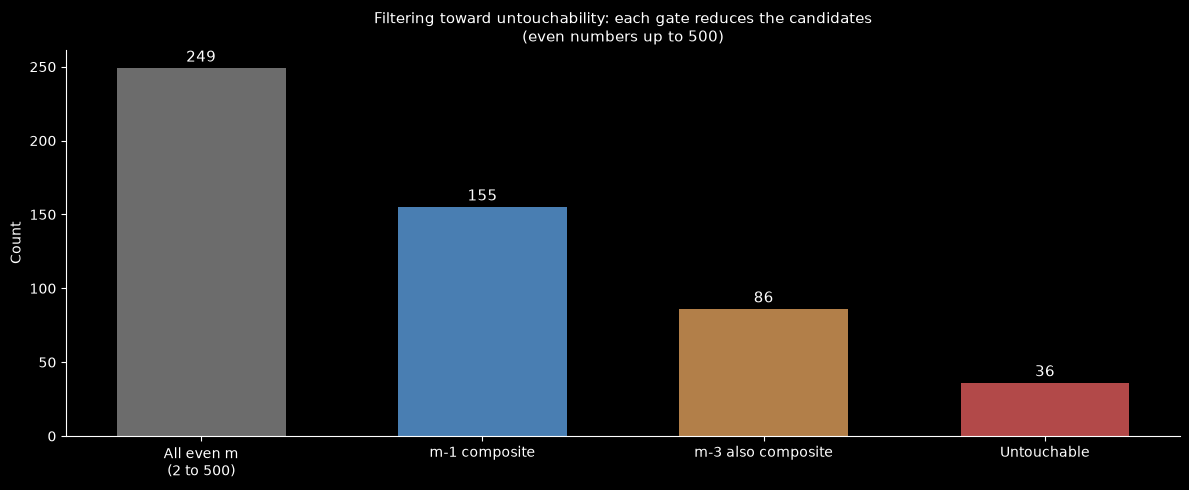

The untouchable numbers are those that pass ALL filters:
  m-1 composite: 155 candidates
  m-3 also composite: 86 candidates
  All algebraic routes blocked: 36 untouchables

Gap between gate2 and actual untouchables: 50
These are touched by other algebraic routes (higher powers, more complex composites)


In [6]:
# Visualise the filtering: how many candidates pass each gate?
fig, ax = plt.subplots(figsize=(12, 5))

# For each even m up to 500, classify:
# Gate 1: m-1 composite (necessary for untouchability)
# Gate 2: m-3 composite (blocks main semiprime route)
# Gate 3: actually untouchable (all routes blocked)

even_nums = list(range(4, 502, 2))
gate1 = [m for m in even_nums if not is_prime(m-1)]
gate2 = [m for m in gate1 if not is_prime(m-3)]
gate3 = [m for m in gate2 if m in set(untouchable)]

categories = ['All even m\n(2 to 500)', 'm-1 composite', 'm-3 also composite', 'Untouchable']
counts     = [len(even_nums), len(gate1), len(gate2), len(gate3)]
colours    = [NEUTRAL, BLUE, AMBER, ACCENT]

bars = ax.bar(categories, counts, color=colours, alpha=0.8, edgecolor='none', width=0.6)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(count), ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Count', fontsize=10)
ax.set_title('Filtering toward untouchability: each gate reduces the candidates\n'
             '(even numbers up to 500)', fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('The untouchable numbers are those that pass ALL filters:')
print(f'  m-1 composite: {len(gate1)} candidates')
print(f'  m-3 also composite: {len(gate2)} candidates')
print(f'  All algebraic routes blocked: {len(gate3)} untouchables')
print()
print(f'Gap between gate2 and actual untouchables: {len(gate2) - len(gate3)}')
print('These are touched by other algebraic routes (higher powers, more complex composites)')

## Erdős's theorem — what IS proved

Paul Erdős did prove something in 1973, conditional on a weak form of Goldbach:

> If Goldbach's Conjecture is true, then the set of untouchable numbers has
> positive **lower asymptotic density** — meaning a positive fraction of all
> integers are untouchable.

Since Goldbach has been verified for all even numbers up to at least 4×10¹⁸,
this conditional result is effectively established computationally for any
range we'd ever encounter.

But "positive density" is a much stronger statement than "infinitely many" in the
sense that it guarantees infinitely many untouchable numbers by itself — you
can't have positive density without infinitely many.

So in practice, we're confident infinitely many untouchable numbers exist.
The issue is that a complete, unconditional proof would require either proving
Goldbach (one of the hardest open problems in mathematics) or finding a different
approach that doesn't depend on it.

Density of untouchable numbers in growing ranges:
       Range     Count     Density
------------------------------------
  1 to   100:         5      0.050
  1 to   200:        20      0.100
  1 to   500:        75      0.150
  1 to  1000:       172      0.172

The density is growing — consistent with Erdős's positive density claim.



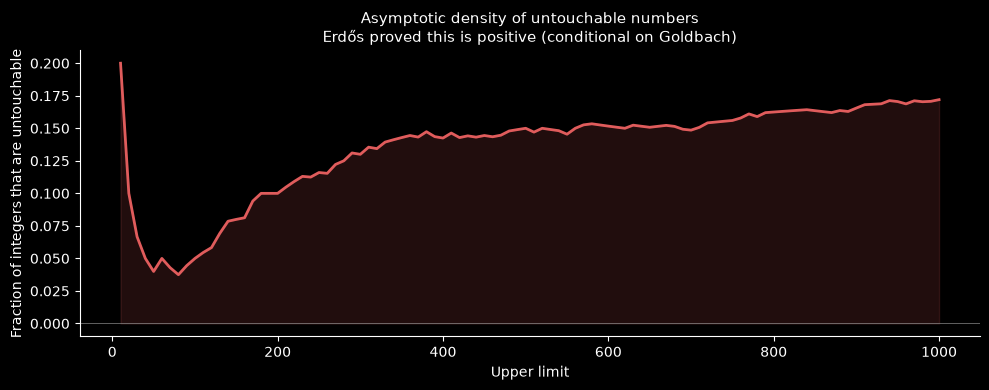

In [7]:
# Verify the density claim: count untouchables in growing ranges
print('Density of untouchable numbers in growing ranges:')
print(f'{"Range":>12}  {"Count":>8}  {"Density":>10}')
print('-' * 36)

for lim in [100, 200, 500, 1000]:
    count = sum(1 for x in untouchable if x <= lim)
    print(f'  1 to {lim:5d}:  {count:>8}  {count/lim:>9.3f}')

print()
print('The density is growing — consistent with Erdős\'s positive density claim.')
print()

# Plot density over range
fig, ax = plt.subplots(figsize=(10, 4))

unt_set = set(untouchable)
xs = list(range(10, LIMIT+1, 10))
densities = [sum(1 for m in untouchable if m <= x) / x for x in xs]

ax.plot(xs, densities, color=ACCENT, linewidth=2)
ax.fill_between(xs, densities, alpha=0.15, color=ACCENT)
ax.axhline(0, color=NEUTRAL, linewidth=0.5)
ax.set_xlabel('Upper limit', fontsize=10)
ax.set_ylabel('Fraction of integers that are untouchable', fontsize=10)
ax.set_title('Asymptotic density of untouchable numbers\n'
             'Erdős proved this is positive (conditional on Goldbach)', fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [8]:
# Goldbach verification for our range
def goldbach_pairs(n):
    """Find pairs (p, q) with p <= q such that p+q = n, both prime."""
    return [(p, n-p) for p in range(2, n//2+1)
            if is_prime(p) and is_prime(n-p)]

print('Goldbach pairs for selected even numbers (verifying the conjecture holds):')
test_evens = [4, 10, 20, 50, 100, 200]
for n in test_evens:
    pairs = goldbach_pairs(n)
    print(f'  {n:4d}: {pairs[:3]}{"..." if len(pairs) > 3 else ""} ({len(pairs)} pairs)')

print()
print('Goldbach verified for all even numbers in our range.')
goldbach_fails = [n for n in range(4, 500, 2) if not goldbach_pairs(n)]
print(f'Even numbers up to 500 where Goldbach fails: {goldbach_fails}')

Goldbach pairs for selected even numbers (verifying the conjecture holds):
     4: [(2, 2)] (1 pairs)
    10: [(3, 7), (5, 5)] (2 pairs)
    20: [(3, 17), (7, 13)] (2 pairs)
    50: [(3, 47), (7, 43), (13, 37)]... (4 pairs)
   100: [(3, 97), (11, 89), (17, 83)]... (6 pairs)
   200: [(3, 197), (7, 193), (19, 181)]... (8 pairs)

Goldbach verified for all even numbers in our range.
Even numbers up to 500 where Goldbach fails: []


## Why the odd untouchable conjecture also connects to Goldbach

The conjecture that 5 is the only odd untouchable number also has a Goldbach flavour.

For an odd number m > 5 to be touchable, we need s(n) = m for some n.
For s(n) to be odd, n must be a perfect square or twice a perfect square
(these are the only forms with an odd number of divisors).

The main routes:
- s(2^k) = 2^k − 1 (covers Mersenne-type odds: 1, 3, 7, 15, 31, ...)
- s(p³) = p² + p + 1 (covers many other odds)
- s(p²q) for various prime combinations

Proving that every odd m > 5 is touched by one of these routes is equivalent
to a statement about the density of certain prime-related values — again,
Goldbach-type territory.

In [9]:
# Show the routes that touch odd numbers
odd_reachable = defaultdict(list)  # m -> list of (n, 'route') pairs

for k in range(1, 20):
    n = 2**k
    s = proper_divisors_sum(n)
    if s % 2 == 1 and s <= 300:
        odd_reachable[s].append((n, f'2^{k}'))

primes_to_100 = [p for p in range(3, 100) if is_prime(p)]
for p in primes_to_100:
    for exp in [3, 5]:
        n = p**exp
        s = proper_divisors_sum(n)
        if s % 2 == 1 and s <= 300:
            odd_reachable[s].append((n, f'{p}^{exp}'))

# What odd numbers up to 50 are NOT in odd_reachable?
odd_not_reached = [m for m in range(3, 100, 2) if m not in odd_reachable and m != 5]
print('Odd numbers up to 99 not reached by 2^k or p^3 or p^5 routes:')
print(odd_not_reached[:20])
print('(These may be reached by other routes: p²q, p²q², etc.)')
print()

print('Sample of odd numbers and their routes:')
for m in [1, 3, 7, 13, 15, 31, 57, 63]:
    routes = odd_reachable.get(m, [])
    route_str = ', '.join(f's({r[1]})' for r in routes[:3])
    print(f'  {m:4d}: {route_str if routes else "no simple route found"}')

Odd numbers up to 99 not reached by 2^k or p^3 or p^5 routes:
[9, 11, 17, 19, 21, 23, 25, 27, 29, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51, 53]
(These may be reached by other routes: p²q, p²q², etc.)

Sample of odd numbers and their routes:
     1: s(2^1)
     3: s(2^2)
     7: s(2^3)
    13: s(3^3)
    15: s(2^4)
    31: s(2^5), s(5^3)
    57: s(7^3)
    63: s(2^6)


## Summary: the precise connection

The relationship between untouchable numbers and Goldbach's Conjecture is:

1. **An even number m is touchable** if m−1 is an odd prime (via s(p²) = m)
   OR if m−3 is an odd prime (via s(2q) = m where q = m−3)
   OR via other, more complex algebraic forms.

2. **An even number m is a candidate for untouchability** only if m−1 is
   composite — this is a necessary condition.

3. **Erdős showed:** if Goldbach's Conjecture is true, then the complement
   (the touchable numbers) has density 1 — almost all numbers are touchable.
   This implies the untouchable numbers have positive density, which implies
   infinitely many.

4. **Without Goldbach**, we cannot rule out the possibility that for large
   enough m, ALL routes to touching m fail — which would mean the untouchable
   numbers eventually stop. This seems wildly unlikely but we can't disprove it
   without Goldbach-level control over the distribution of primes.

**Next:** Notebook 3 — The wall. What exactly does it mean that this is blocked
by Goldbach? What would a proof look like, and why don't we have one?